# Heart Disease Analysis

In this notebook we analyze the **Heart Disease** dataset from Kaggle (`heart.csv`),
which contains clinical data from 1,025 patients.

The goal is to predict whether a patient has heart disease using variables
such as age, cholesterol, heart rate, and others.

**Analysis workflow:**
1. Initial data exploration
2. Exploratory Data Analysis (EDA) and visualizations
3. Correlation matrix to identify good predictors
4. Classification model with Logistic Regression
5. Model evaluation

## Libraries and dataset

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('heart.csv')

# Primera mirada
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [45]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [46]:
# Ver balance de la variable objetivo
#cuenta cuantos son 0 y cuantos son 1
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

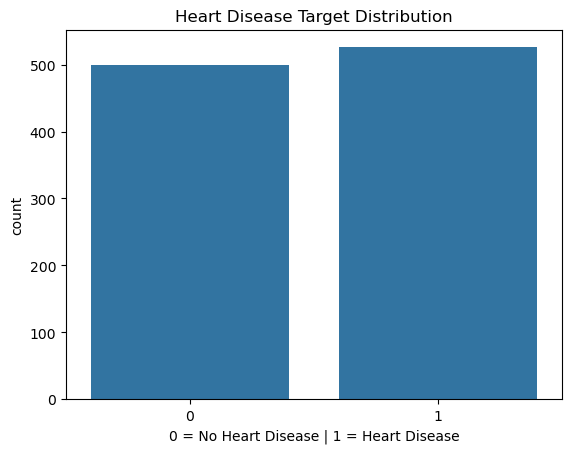

In [47]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Target Distribution')
plt.xlabel('0 = No Heart Disease | 1 = Heart Disease')

plt.savefig('target_distribution.png')
plt.show()

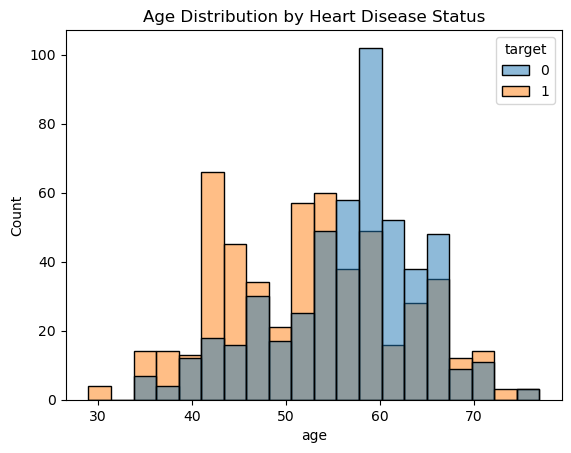

In [48]:
# Distribución de edad por enfermedad
sns.histplot(data=df, x='age', hue='target', bins=20)
plt.title('Age Distribution by Heart Disease Status')

plt.savefig('age_distribution.png')
plt.show()

## Age distribution

According to the figure, younger patients (40–55 years) tend to have heart disease (target = 1),
while older patients (55–70 years) tend not to (target = 0).

This is counterintuitive — one would expect the opposite. A likely explanation is that
this is a clinical dataset from a specific hospital: younger patients came in precisely
because of real cardiac symptoms, while older patients visited for other reasons.

This is known as **selection bias** — the data does not represent the general population,
but rather patients from a specific clinical center.



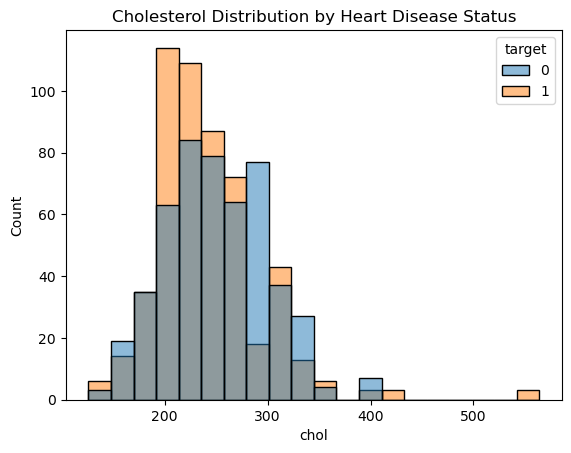

In [49]:
# Distribución de la variable colesteerol 
sns.histplot(data=df, x='chol', hue='target', bins=20)
plt.title('Cholesterol Distribution by Heart Disease Status')

plt.savefig('chol_distribution.png')
plt.show()

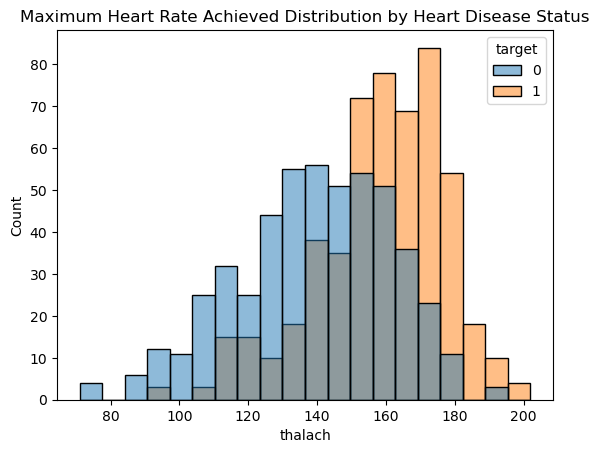

In [50]:
# Distribución de edad por enfermedad
sns.histplot(data=df, x='thalach', hue='target', bins=20)
plt.title('Maximum Heart Rate Achieved Distribution by Heart Disease Status')

plt.savefig('thalach_distribution.png')
plt.show()

## Cholesterol and heart rate distribution

**Cholesterol (chol):** not a good predictor of heart disease — the distributions 
of both groups overlap heavily, making it difficult to distinguish between them.

**Maximum heart rate (thalach):** shows clear separation between groups. 
Patients with heart disease (1) tend to reach higher maximum heart rates. 
Strong predictor.

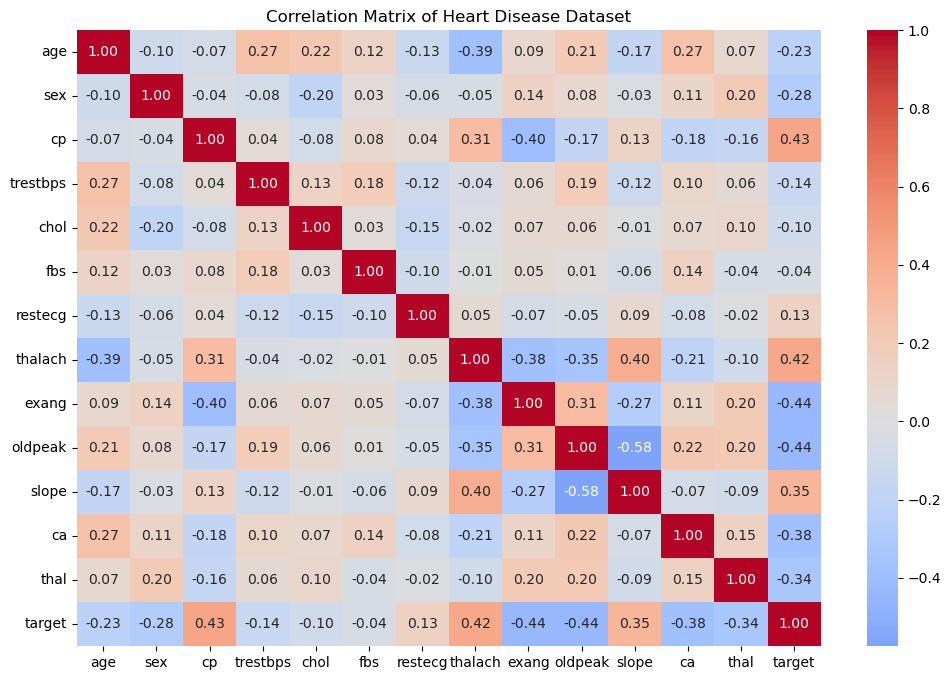

In [51]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Heart Disease Dataset')

plt.savefig('correlation_matrix.png')
plt.show()

## Correlation matrix

Based on the last column, which tells us how well each variable predicts the target:

- **cp (+0.43)** and **thalach (+0.42)**: strongest positive predictors
- **exang (-0.44)** and **oldpeak (-0.44)**: strongest negative predictors
- **chol (-0.10)**: confirms what we saw earlier — weak predictor

The rest of the matrix shows how the variables correlate with each other.

In [52]:
#scikit learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Separar features y target
#drop elimina la columna target del df y lo asigna a X, mientras que y se queda solo con la columna target

X = df.drop('target', axis=1)
y = df['target']
#X (1025 filas, 13 columnas)  →  X_train (820 filas)  +  X_test (205 filas)
#y (1025 filas, 1 columna)    →  y_train (820 filas)  +  y_test (205 filas)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#1025 × 0.8 = 820  → entrenamiento
#1025 × 0.2 = 205  → prueba
print(f'Entrenamiento: {X_train.shape[0]} pacientes')
print(f'Prueba: {X_test.shape[0]} pacientes')

Entrenamiento: 820 pacientes
Prueba: 205 pacientes


In [53]:
# Entrenar el modelo
#crea el modelo y max_iter=1000 le dice que intente hasta 1000 iteraciones para converger (la mejor solucion)
model = LogisticRegression(max_iter=1000)
#ahora el modelo se entrena con los datos de entrenamiento (X_train, y_train)
#le da sus 820 pacientes con sus variables X_train y su diagnostico real y_train para que aprenda a predecir
#y ajusta internamente los parametros para encontrar la mejor forma de predecir la variable objetivo (target)
model.fit(X_train, y_train)

# Predecir en el conjunto de prueba. Le das los 250 pacientes X_test (solo las variablees sin el diagnostico) y 
# #el modelo te devuelve sus predicciones (y_pred)
y_pred = model.predict(X_test)

# Accuracy
# compara las predicciones del modelo (y_pred) con los diagnosticos reales (y_test) y calcula el porcentaje de aciertos
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

Accuracy: 0.80


In [54]:
print(classification_report(y_test, y_pred, 
      target_names=['Sin enfermedad', 'Con enfermedad']))



                precision    recall  f1-score   support

Sin enfermedad       0.85      0.72      0.78       102
Con enfermedad       0.76      0.87      0.81       103

      accuracy                           0.80       205
     macro avg       0.80      0.79      0.79       205
  weighted avg       0.80      0.80      0.79       205



## Classification report

**No heart disease**
- Support = 102 healthy patients in the test set
- Recall = 0.72 → detected 72% of those 102, i.e. 73 patients correctly
- Precision = 0.85 → of all predicted as healthy, 85% actually were

**Heart disease**
- Support = 103 sick patients in the test set
- Recall = 0.87 → detected 87% of those 103, i.e. 90 patients correctly
- Precision = 0.76 → of all predicted as sick, 76% actually were

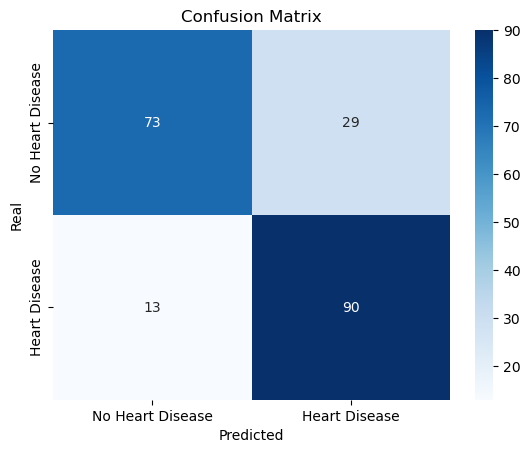

In [55]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Real')
plt.xlabel('Predicted')

plt.savefig('confusion_matrix.png')
plt.show()

## Confusion matrix

**Diagonal values — correct predictions:**
- 73: healthy patients correctly predicted as healthy
- 90: sick patients correctly predicted as sick

**Off-diagonal values — errors:**
- 29: healthy patients incorrectly predicted as sick (false positives)
- 13: sick patients incorrectly predicted as healthy (false negatives — most critical)

## Conclusions

### Data
- Dataset of 1,025 patients with 13 clinical variables
- Near-perfect class balance: 526 with disease (51%) and 499 healthy (49%)
- No missing values — no cleaning required

### EDA findings
- **cp** and **thalach** are the strongest positive predictors of heart disease
- **exang** and **oldpeak** are the strongest negative predictors
- **chol** showed heavily overlapping distributions between groups — weak predictor
- Younger patients (40–55) tend to have heart disease, likely due to selection bias

### Model
- Logistic Regression with 80% accuracy
- Recall of 0.87 for sick patients — detects 87% of real cases
- Most critical error: 13 false negatives (sick patients classified as healthy)

### Next steps
- Test other models (Random Forest, SVM)
- Optimize hyperparameters
- Analyze feature importance

## A resaltar

- **Train (820):** entran al `model.fit()`. El modelo aprende con ellos y ya.
- **Test (205):** entran al `model.predict()`. El accuracy, matriz de confusión 
  y classification report son todos sobre estos datos.

Una vez entrenado el modelo, los datos de train cumplieron su función. 
Todo lo que se reporta en el proyecto es sobre test.